# **Week4 (Classification) 과제**

# Red Wine Quality Classification

## 데이터 소개
  
UCI Machine Learning  
**TASK : Red wine Classification**  
https://archive.ics.uci.edu/dataset/186/wine+quality


csv 파일의 컬럼은 아래와 같습니다.

*   index : 구분자
*   quality : 품질
*   fixed acidity : 산도
*   volatile acidity : 휘발성산
*   citric acid : 시트르산
*   residual sugar 잔당 : 발효 후 와인 속에 남아있는 당분
*   chlorides : 염화물
*   free sulfur dioxide : 독립 이산화황
*   total sulfur dioxide : 총 이산화황
*   density : 밀도
*   pH : 수소이온농도
*   sulphates : 황산염
*   alcohol : 도수
*   type : 종류



In [1]:
# 코랩 환경: 구글 드라이브에 코랩을 연동
# from google.colab import drive
# drive.mount('/content/drive')

In [2]:
# necessary imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
%matplotlib inline

In [3]:
# loading data ,your own file path
# (Colab 사용 시) df = pd.read_csv('/content/drive/MyDrive/본인 드라이브 주소/winequality-red.csv', sep = ';')
# UCI 원본 파일은 세미콜론(;)으로 구분되어 있으므로 sep = ';' 을 지정한다.
df = pd.read_csv('winequality-red.csv', sep = ';')

## EDA(Exploratory Data Analysis)

In [4]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


### Q1 Data brief review : info() 함수를 통해 알아낼 수 있는 정보를 작성하시오. 
(**빈칸 ## 4개를 채우시오**)


답: It turns out that the dataset does not have (**null(결측)**) values. The dataset consists of (**1599**) rows and (**12**) columns. The data type of all variables are (**numerical - 설명변수 11개는 float64, 종속변수 quality는 int64**).

- `df.info()` 결과 모든 컬럼의 Non-Null Count가 1599로 전체 행 수와 동일하므로 결측치가 없다.
- 12개 컬럼이 모두 수치형(float64 11개 + int64 1개)이므로, 별도의 인코딩(one-hot 등) 없이 바로 모델 입력으로 사용할 수 있다. 다만 스케일 차이가 크므로 스케일링은 필요하다.


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [6]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


### Q2 결측치 확인
결측치가 존재한다면, 이를 처리하는 방법에 대해 알아보고 정리해주세요.

결측치는 판단에 따라 drop(제거) 할 수 있고, 특정 값으로 채울(대체) 수 있습니다.

데이터를 채우는 방법으로는 수치형 데이터는 통계를 이용해서, 범주형 데이터는 unique(), value_counts() 등으로 처리합니다.

In [7]:
# 결측치 확인
## df의 결측치의 총 합을 확인하는 코드를 작성하며, ##을 채우세요. sum()을 2번 사용하시오.

print("There are {} null values in the dataset".format(df.isnull().sum().sum()))

There are 0 null values in the dataset


### Q3 데이터 분포 확인
각 변수의 데이터 분포가 어떠한지 기술하시오.(맨 위의 세개의 변수에 대해서만 기술)

1. **'fixed_acidity'** : 4.6 ~ 15.9 범위, 평균 8.32 / 중앙값 7.9로 **평균 > 중앙값**인 오른쪽으로 꼬리가 긴 우측 편포(skewness ≈ 0.98)이다. 대부분의 관측치가 7~9 사이에 밀집해 있고, 12 이상의 산도가 매우 높은 와인이 소수 존재해 꼬리를 만든다.

2. **'volatile_acidity'** : 0.12 ~ 1.58 범위, 평균 0.53 / 중앙값 0.52로 비교적 대칭에 가까우나 여전히 약한 우측 편포(skewness ≈ 0.67)를 보인다. 0.3~0.7 구간에 집중되어 있으며 0.4 부근과 0.6 부근에 봉우리가 나타나는 다봉(bimodal)에 가까운 형태이고, 1.0 이상의 극단값이 소수 관측된다.

3. **'citric_acid'** : 0 ~ 1.0 범위, 평균 0.27 / 중앙값 0.26으로 세 변수 중 가장 대칭에 가깝지만(skewness ≈ 0.32), **값이 정확히 0인 관측치가 132개**로 0 지점에 뾰족한 스파이크가 존재하는 불연속적 분포이다. 첨도가 -0.79로 음수여서 특정 값에 몰리기보다 0~0.5 구간에 넓고 평평하게(균등분포에 가깝게) 퍼져 있다.


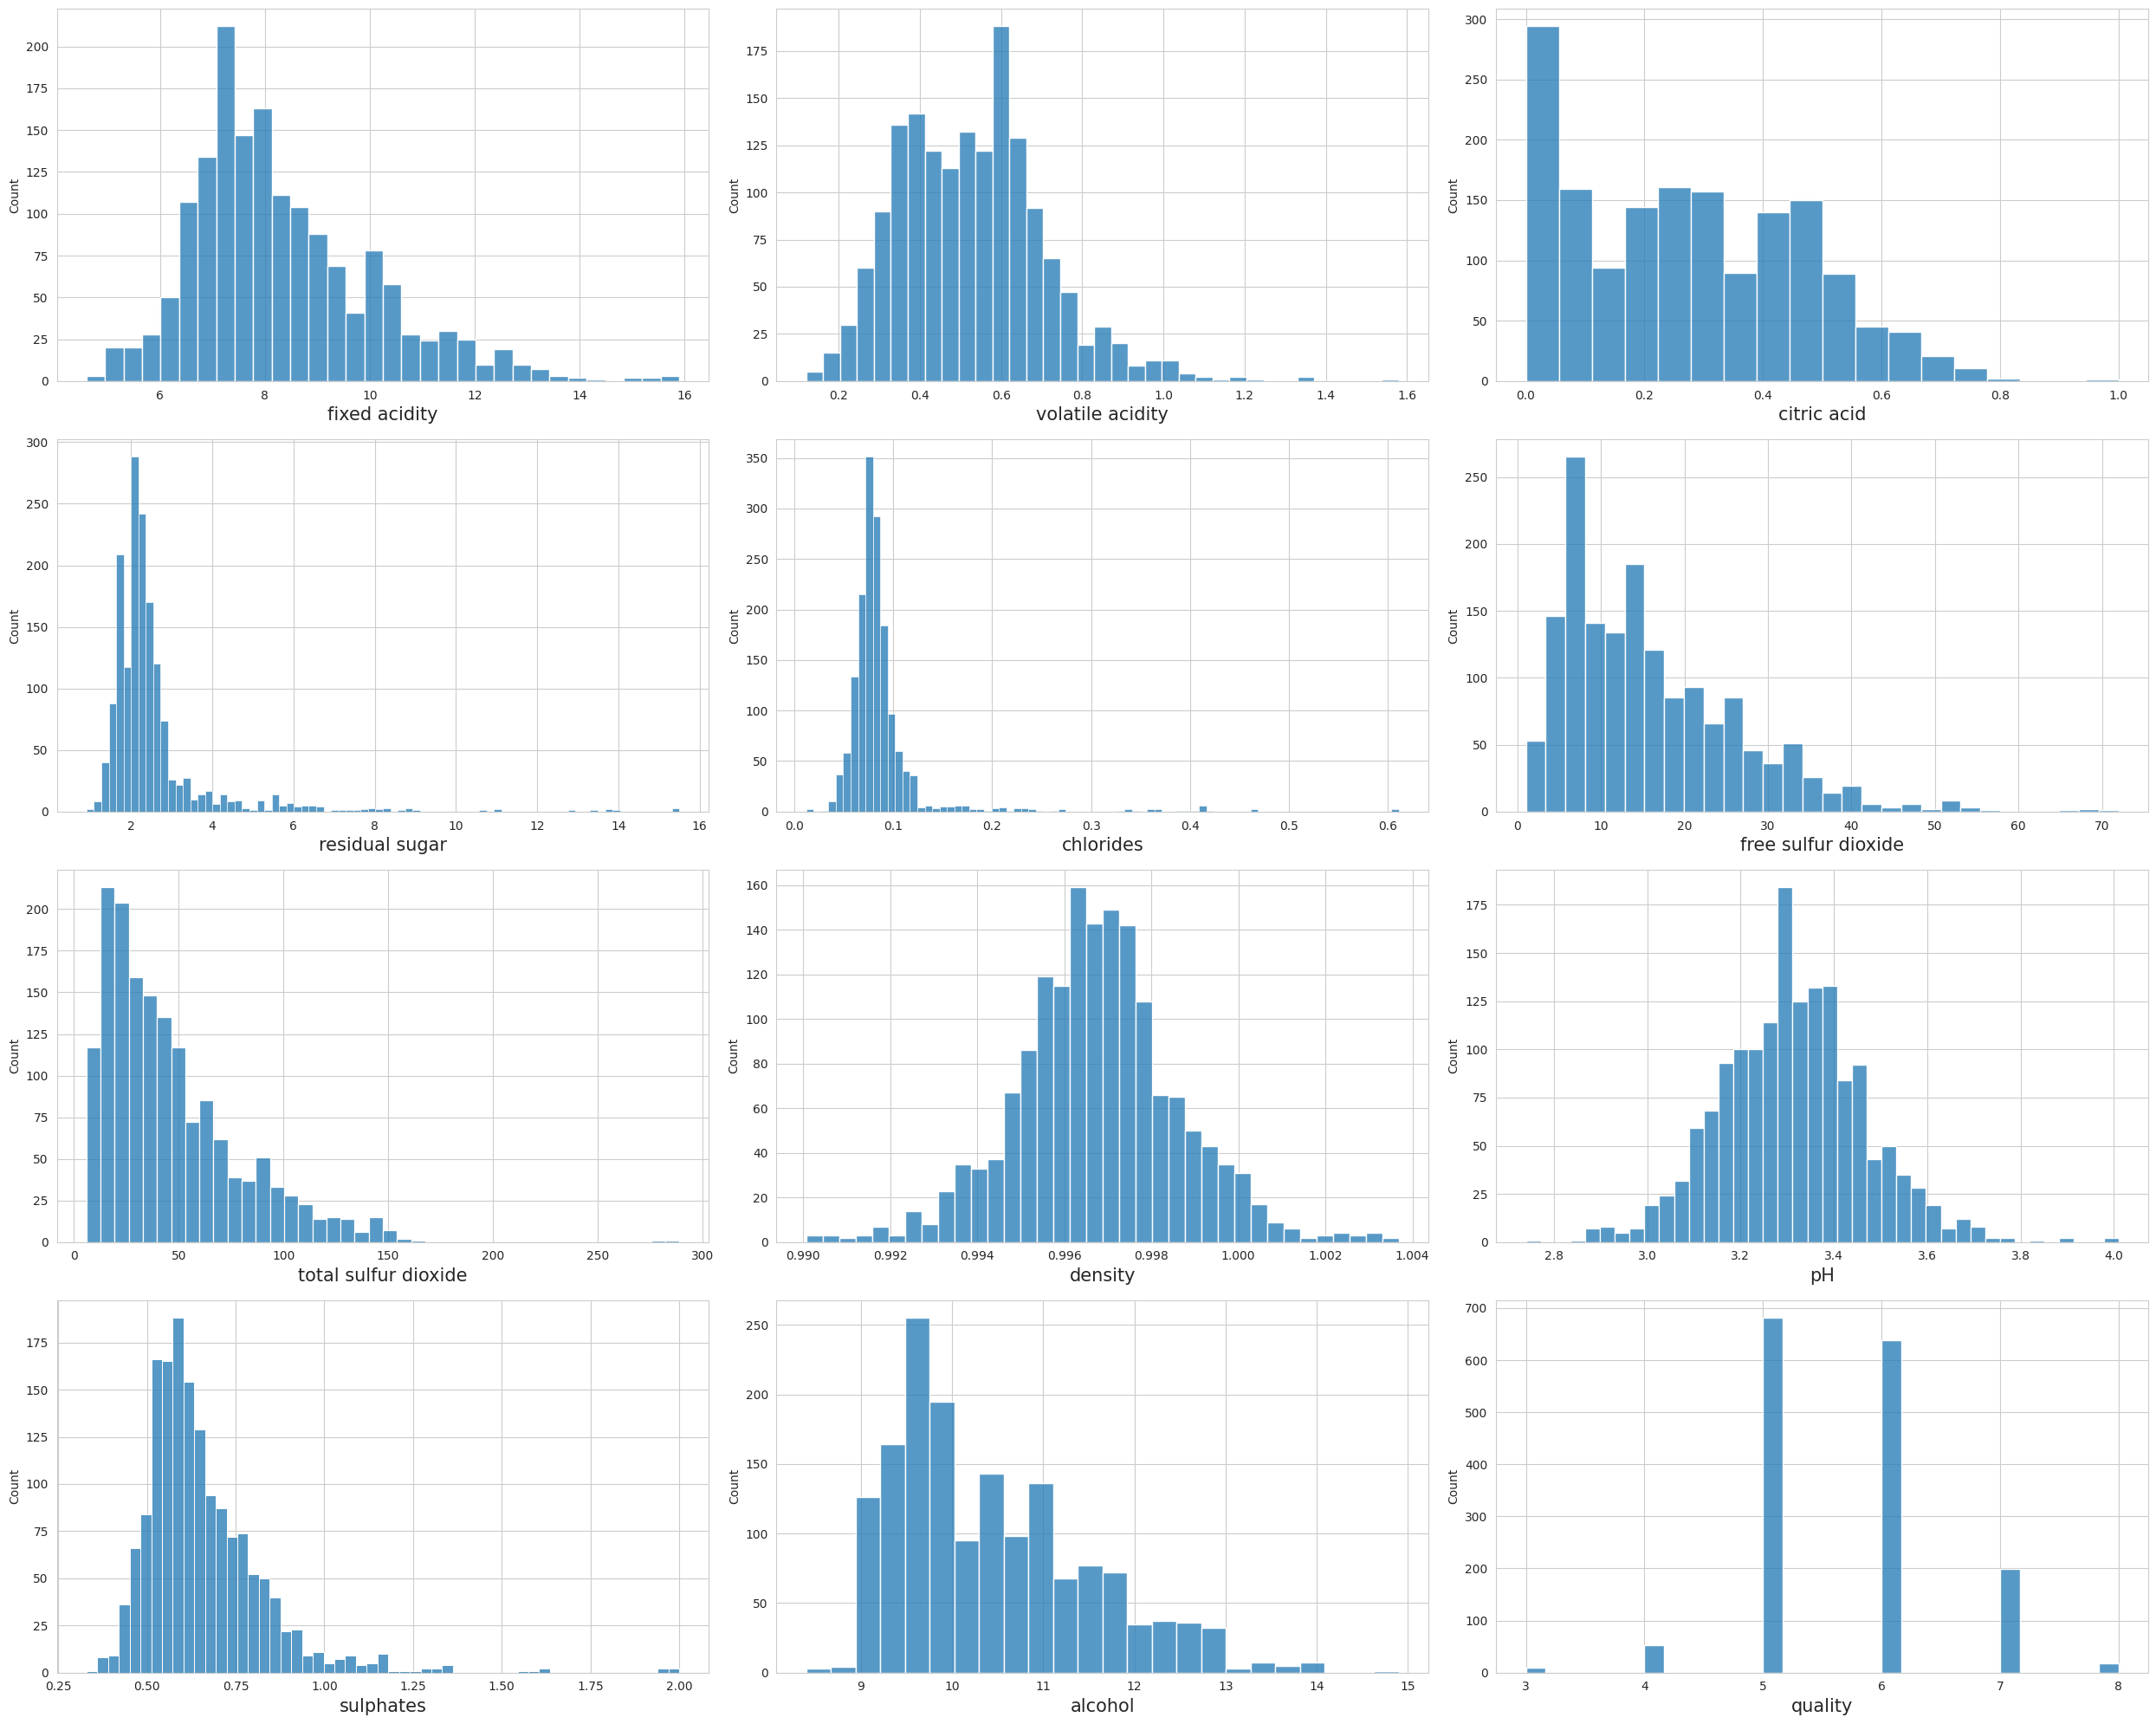

In [8]:
# let's see how data is distributed for every column
plt.figure(figsize = (25, 20))
plotnumber = 1

for col in df:
    if plotnumber <= 12:
        ax = plt.subplot(4, 3, plotnumber)
        sns.histplot(df[col])
        plt.xlabel(col, fontsize = 15)

    plotnumber += 1

plt.tight_layout()
plt.show()

### Q4. correlation plot을 그리고, 해당 plot에서 얻은 인사이트를 정리해보세요.

더불어 multicollinearity(통계학의 회귀분석에서 독립변수들 간에 강한 상관관계가 나타나는 문제)에 주목하여, 해당 correlation plot에서 어떤 영향을 주고 있는지 있는지 예를 들어 기술하시오.

답:

**(1) 종속변수 quality와의 관계**
- `alcohol` (r = 0.48)이 가장 강한 양의 상관을 보이고, 그 다음으로 `sulphates`(0.25), `citric acid`(0.23)가 양의 상관을 가진다.
- `volatile acidity` (r = -0.39)는 가장 강한 음의 상관을 보인다. 휘발성 산은 와인의 식초 냄새와 직결되므로 값이 클수록 품질이 낮아진다는 도메인 지식과 일치한다.
- `residual sugar`(0.01), `free sulfur dioxide`(-0.05), `pH`(-0.06)는 quality와 거의 무상관이어서 단독 예측력은 낮다.

**(2) 설명변수 간의 관계 = multicollinearity**
- `fixed acidity`가 여러 변수와 동시에 강하게 얽혀 있다: `pH`와 **-0.68**, `density`와 **+0.67**, `citric acid`와 **+0.67**.
- `free sulfur dioxide` ↔ `total sulfur dioxide` : **+0.67**. total은 free를 포함하는 개념이므로 사실상 정보가 중복된다.
- `alcohol` ↔ `density` : **-0.50**. 알코올은 물보다 밀도가 낮으므로 물리적으로 필연적인 관계이다.
- `volatile acidity` ↔ `citric acid` : **-0.55**.

**(3) multicollinearity가 주는 영향과 대응**
- 회귀 계열 모델에서 위와 같이 상관이 높은 변수들이 함께 들어가면 $(X^TX)$가 거의 특이행렬에 가까워져 **계수 추정치의 분산이 팽창(VIF 증가)**한다. 그 결과 계수의 크기와 **부호가 표본에 따라 뒤집히는** 불안정성이 생긴다. 예를 들어 `fixed acidity`, `citric acid`, `pH`를 모두 넣으면 셋 다 '산도'라는 동일한 정보를 나눠 갖게 되어 개별 계수의 해석("산도가 1 증가할 때 품질 변화")이 사실상 무의미해진다.
- 대응 방법: 중복 변수 제거(예: `total sulfur dioxide`만 남기기), VIF 기준 변수 선택, PCA 등 차원축소, Ridge와 같은 규제 적용.
- 다만 이번 과제에서 사용하는 **KNN이나 트리 계열 모델은 계수 추정을 하지 않으므로 다중공선성이 예측 성능 자체를 크게 훼손하지는 않는다.** 대신 상관된 변수가 중복 계상되어 거리 계산에서 특정 정보(산도)에 **과도한 가중치**가 실리거나, 트리의 변수 중요도가 상관 변수끼리 분산되어 해석이 왜곡되는 형태로 영향을 준다.


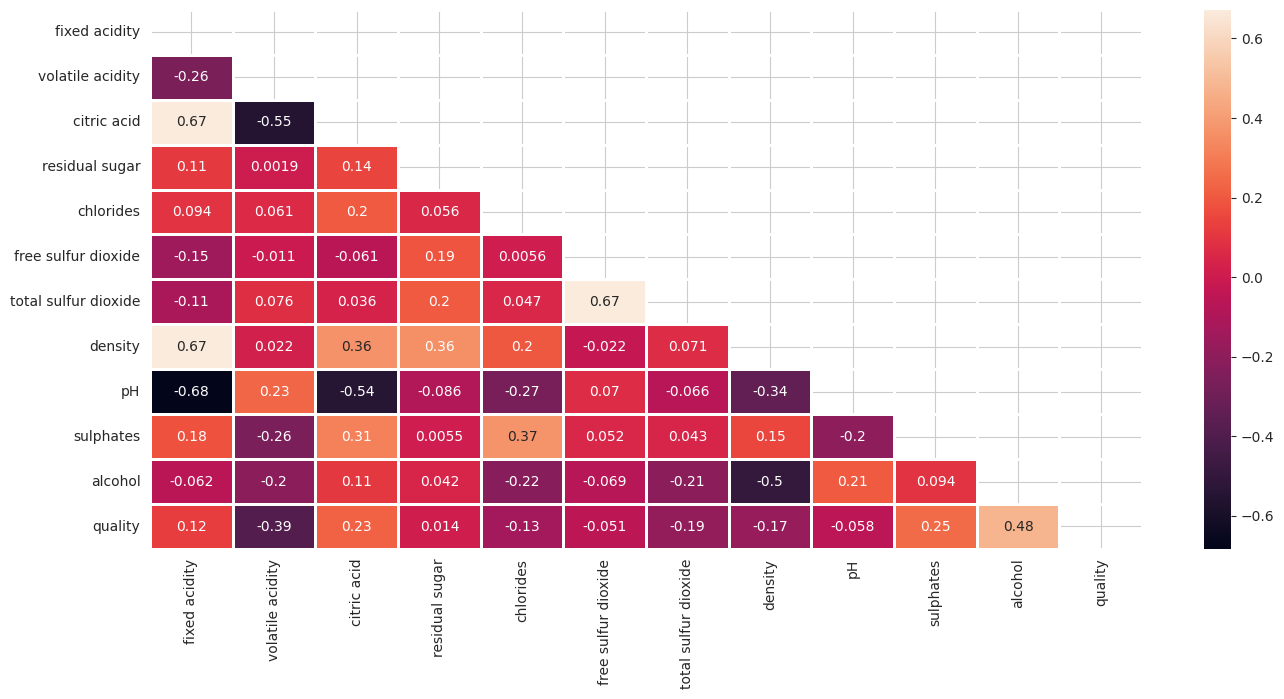

In [9]:
# 상관관계 plot
plt.figure(figsize = (16, 7))

corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype = bool))

sns.heatmap(corr, mask = mask, annot = True, fmt = '0.2g', linewidths = 1)
plt.show()

In [10]:
#Pearson correlation coefficient
import scipy.stats as st
print("Pearson correlation coefficient:", st.pearsonr(df["alcohol"],df["density"]))
print("Pearson correlation coefficient:", st.pearsonr(df["free sulfur dioxide"],df["total sulfur dioxide"]))
print("Pearson correlation coefficient:", st.pearsonr(df["fixed acidity"],df["pH"]))
print("Pearson correlation coefficient:", st.pearsonr(df["citric acid"],df["pH"]))
print("Pearson correlation coefficient:", st.pearsonr(df["fixed acidity"],df["density"]))

Pearson correlation coefficient: PearsonRResult(statistic=np.float64(-0.4961797702417017), pvalue=np.float64(3.938835339988381e-100))
Pearson correlation coefficient: PearsonRResult(statistic=np.float64(0.6676664504810215), pvalue=np.float64(6.404722954681827e-207))
Pearson correlation coefficient: PearsonRResult(statistic=np.float64(-0.6829781945685316), pvalue=np.float64(4.0630340398421645e-220))
Pearson correlation coefficient: PearsonRResult(statistic=np.float64(-0.5419041447395097), pvalue=np.float64(1.0072013259114716e-122))
Pearson correlation coefficient: PearsonRResult(statistic=np.float64(0.6680472921189734), pvalue=np.float64(3.0747470608610657e-207))


### Q5. quality range를 두 파트로 나눠보세요.
In this dataset quality range is between 3 and 8
We will divide quality range into two parts:



*   High quality wine: 6 - 8
*   Low quality wine: 3 - 5



In [11]:
# quality >= 6 이면 High quality(1), quality <= 5 이면 Low quality(0)
df["quality"] = df["quality"].apply(lambda x: 1 if x >= 6 else 0)
df["quality"]

0       0
1       0
2       0
3       1
4       0
       ..
1594    0
1595    1
1596    1
1597    0
1598    1
Name: quality, Length: 1599, dtype: int64

In [12]:
df.head().style.background_gradient(cmap = "Reds")

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.400000,0.700000,0.000000,1.900000,0.076000,11.000000,34.000000,0.997800,3.510000,0.560000,9.400000,0
1,7.800000,0.880000,0.000000,2.600000,0.098000,25.000000,67.000000,0.996800,3.200000,0.680000,9.800000,0
2,7.800000,0.760000,0.040000,2.300000,0.092000,15.000000,54.000000,0.997000,3.260000,0.650000,9.800000,0
3,11.200000,0.280000,0.560000,1.900000,0.075000,17.000000,60.000000,0.998000,3.160000,0.580000,9.800000,1
4,7.400000,0.700000,0.000000,1.900000,0.076000,11.000000,34.000000,0.997800,3.510000,0.560000,9.400000,0


### Q6. 종속변수(y,label)은 무엇이 되어야 하나요?

답: **`quality`** 가 종속변수(y)가 되어야 한다. 우리가 예측하려는 대상이 '이 와인이 고품질(1)인가 저품질(0)인가'이고, Q5에서 이미 0/1 이진 레이블로 변환했으므로 `quality`를 y로, 나머지 11개의 물리·화학적 측정값을 설명변수 x로 사용한다. 이때 `quality`가 x에 남아 있으면 정답이 그대로 입력으로 들어가는 data leakage가 되므로 반드시 `drop` 해야 한다.


In [13]:
# we select dependent variable (label)
y = df["quality"]

# we select independent variable
x = df.drop("quality", axis = 1)

In [14]:
# splitting data into training and test set
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y,
                                                    test_size = 0.25,
                                                    shuffle = True,
                                                    random_state = 1)

### Q7. 왜 Standardization(StandardScaler, MinMaxScaler 등) 사용할까요? 
두 Scaler의 특징에 대해 조사하고, 보다 적절한 Scaler가 무엇일지 그 이유와 함께 적어주세요.

답 :

**왜 필요한가**
이 데이터의 변수들은 단위와 범위가 크게 다르다. `total sulfur dioxide`는 6~289, `density`는 0.99~1.00, `chlorides`는 0.01~0.61 수준이다. 스케일링 없이 KNN처럼 **거리 기반**으로 동작하는 모델에 넣으면 유클리드 거리 계산에서 값의 범위가 큰 `total sulfur dioxide`가 거리를 거의 독점하고, `density`나 `chlorides`의 차이는 사실상 무시된다. 즉 변수 간 **기여도를 공정하게 맞춰주기 위해** 스케일링이 필요하다. (규제가 있는 회귀나 경사하강법 기반 모델에서도 수렴 속도·규제 강도의 공정성 때문에 필요하다. 반대로 트리 계열은 분기 기준이 순서에만 의존하므로 스케일링이 불필요하다.)

**두 Scaler의 특징**

| | StandardScaler | MinMaxScaler |
|---|---|---|
| 변환식 | $(x-\mu)/\sigma$ | $(x - x_{min})/(x_{max}-x_{min})$ |
| 결과 | 평균 0, 표준편차 1 | 지정 범위(보통 [0, 1])로 고정 |
| 범위 | 고정되지 않음 | 고정됨 |
| 이상치 | 평균·표준편차를 쓰므로 **상대적으로 덜 민감** | min/max 단 두 값에 의존해 **매우 민감** |
| 분포 모양 | 유지 | 유지 |

**어느 것이 더 적절한가**
이 데이터는 Q3에서 확인했듯 `fixed acidity`, `residual sugar`, `chlorides` 등 대부분의 변수가 우측으로 크게 치우쳐 있고 극단값이 존재한다. MinMaxScaler는 이 극단값 하나가 분모($x_{max}-x_{min}$)를 결정하기 때문에, 나머지 대다수 관측치가 0에 가까운 좁은 구간에 눌려 압축되는 문제가 생긴다. 따라서 **이론적으로는 이상치에 덜 민감한 StandardScaler(혹은 사분위수를 쓰는 RobustScaler)가 더 적절**하다고 판단된다.

다만 본 과제 코드는 `feature_range = (0, 1)` 인자가 주어져 있으므로 **MinMaxScaler**를 사용한다. KNN 관점에서는 모든 변수의 기여 범위를 [0, 1]로 동일하게 맞춘다는 직관적 장점이 있고, 실제 이 데이터에서 두 스케일러의 성능 차이는 크지 않을 것으로 예상된다.


In [15]:
# scaling data
from sklearn.preprocessing import MinMaxScaler

norm = MinMaxScaler(feature_range = (0, 1))
norm.fit(x_train)                    # 스케일링 기준(min, max)은 train set에서만 학습
x_train = norm.transform(x_train)    # norm.fit(x_train) + norm.transform(x_train) = norm.fit_transform(x_train)
x_test = norm.transform(x_test)      # test set에는 학습된 기준을 적용만 한다

### Q7-2. 위의 코드에서, train dataset에 대해서는 fit_transform을, test dataset에 대해서는 transform을 실시하는 이유가 무엇일지 조사해주세요.
답 :

**핵심은 데이터 누수(data leakage) 방지이다.**

1. **test set은 '아직 보지 못한 미래의 데이터'를 모사해야 한다.** 만약 test set에 `fit_transform`을 하면 스케일링 기준인 min/max(또는 평균·표준편차)를 계산하는 과정에서 test set의 분포 정보가 전처리 단계로 흘러 들어간다. 실제 서비스 상황에서는 새로 들어올 데이터의 min/max를 미리 알 수 없으므로, 이는 현실에서 불가능한 정보를 사용하는 것이며 결과적으로 **평가 성능이 낙관적으로 과대추정**된다.

2. **train과 test에 서로 다른 변환 규칙이 적용되면 안 된다.** 각각 fit을 하면 두 집합의 min/max가 달라져 **동일한 원본 값이 서로 다른 값으로 매핑**된다. 예를 들어 alcohol = 11.0이 train에서는 0.35, test에서는 0.42가 되어 버리면, train 기준으로 학습된 결정 경계가 test에서는 다른 의미를 갖게 되어 모델 입력의 정합성이 깨진다.

3. 따라서 **전처리기(scaler)도 모델의 일부로 간주하여 train에서만 학습(fit)하고, test에는 그 학습된 규칙을 적용(transform)만** 해야 한다. 같은 이유로 교차검증을 할 때도 fold마다 스케일링을 다시 fit 해야 하며, 이를 안전하게 처리하기 위해 실무에서는 `Pipeline`으로 scaler와 모델을 묶어 사용한다.


In [16]:
print(x_train[0:5])
print("\n")
print(x_train.shape)
print("_________________________________________________________________________")
print(x_test[0:5])
print("\n")
print(x_test.shape)

[[0.23893805 0.1369863  0.23       0.10769231 0.090301   0.47887324
  0.23529412 0.4441896  0.54330709 0.17365269 0.26153846]
 [0.32743363 0.38013699 0.26       0.09230769 0.12040134 0.14084507
  0.13602941 0.57568807 0.4488189  0.11976048 0.12307692]
 [0.69911504 0.17808219 0.6        0.13076923 0.11538462 0.42253521
  0.24264706 0.72859327 0.28346457 0.23952096 0.32307692]
 [0.36283186 0.44178082 0.22       0.10769231 0.08695652 0.11267606
  0.13235294 0.47629969 0.28346457 0.13173653 0.15384615]
 [0.32743363 0.49657534 0.01       0.1        0.09698997 0.05633803
  0.02941176 0.50688073 0.45669291 0.1497006  0.4       ]]


(1199, 11)
_________________________________________________________________________
[[0.37168142 0.19863014 0.64       0.1        0.13545151 0.11267606
  0.13235294 0.65214067 0.62992126 0.19760479 0.32307692]
 [0.36283186 0.34931507 0.28       0.13846154 0.14046823 0.22535211
  0.23161765 0.5558104  0.40944882 0.17964072 0.27692308]
 [0.51327434 0.15068493 0.58  

In [17]:
print(y_train.head())
print(y_train.shape)
print("___________________________")
print(y_test.head())
print(y_test.shape)

1144    0
73      0
446     0
399     0
647     0
Name: quality, dtype: int64


(1199,)
___________________________
75      0
1283    1
408     1
1281    1
1118    1
Name: quality, dtype: int64
(400,)


### Q8. Building Classification models

이번 코드에서는 non parametric model; knn을 사용하여 train, test 진행해보았습니다.

아래의 코드 외에도 원하는 한가지 classification 모델(KNN 제외)을 선정하여 아래의 과정을 반복하고, 그 결과를 해석하세요. grid search 과정은 거치지 않고 임의의 파라미터값으로 진행해도 좋습니다.

아래와 같은 Kaggle 코드들도 참고해보세요.  
- https://www.kaggle.com/code/melissamonfared/red-wine-quality-prediction-eda-classification/notebook
- https://www.kaggle.com/code/eisgandar/red-wine-quality-eda-classification


In [18]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
#KNN

knn = KNeighborsClassifier()

knn_params = {"n_neighbors": np.arange(2, 50),
             "weights": ["uniform", "distance"],
             "leaf_size": [25, 30, 25]}

knn_cv_model = GridSearchCV(knn, knn_params, cv = 10)
knn_cv_model.fit(x_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'leaf_size': [25, 30, ...], 'n_neighbors': array([ 2, 3..., 47, 48, 49]), 'weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is disp

In [19]:
print("Best score for train set: " + str(knn_cv_model.best_score_))

print("____________________________________________")

print("best K value: " + str(knn_cv_model.best_params_["n_neighbors"]),
     "\nbest weights: " + knn_cv_model.best_params_["weights"],
     "\nbest leaf size: " + str(knn_cv_model.best_params_["leaf_size"]))

Best score for train set: 0.798172268907563
____________________________________________
best K value: 21 
best weights: distance 
best leaf size: 25


In [20]:
knn_model = KNeighborsClassifier(n_neighbors = knn_cv_model.best_params_["n_neighbors"],
                                leaf_size = knn_cv_model.best_params_["leaf_size"],
                                weights = knn_cv_model.best_params_["weights"])

knn_model.fit(x_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",np.int64(21)
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'distance'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",25
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [21]:
from sklearn.metrics import accuracy_score
y_pred = knn_model.predict(x_test)
print("Accuracy:",accuracy_score(y_test, y_pred)) #Validation Set Accurac

Accuracy: 0.8025


In [22]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.78      0.81      0.79       188
           1       0.82      0.80      0.81       212

    accuracy                           0.80       400
   macro avg       0.80      0.80      0.80       400
weighted avg       0.80      0.80      0.80       400



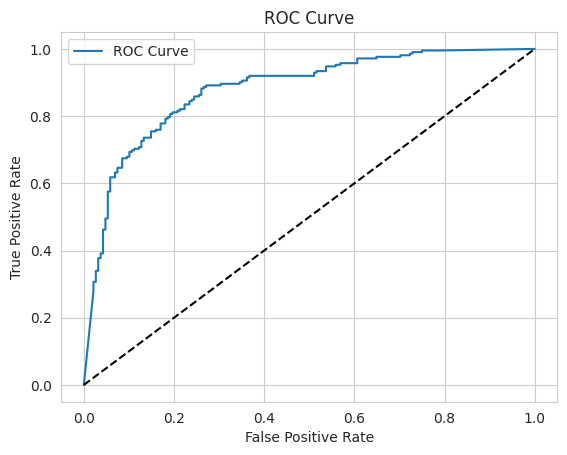

In [23]:
from sklearn.metrics import roc_curve, roc_auc_score
# Validation Set 에 대한 예측확률 계산
y_prob = knn_model.predict_proba(x_test)[:,1]

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label = "ROC Curve")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [24]:
## 아래의 과정을 반복하시오.
## 선정 모델 : Random Forest (KNN 제외, parametric/거리기반이 아닌 앙상블 트리 모델)

from sklearn.ensemble import RandomForestClassifier

# grid search 없이 임의의 파라미터값으로 진행 (트리 300개, 깊이 제한 없음)
rf_model = RandomForestClassifier(n_estimators = 300,
                                  max_depth = None,
                                  random_state = 1)

rf_model.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [25]:
# Accuracy
y_pred_rf = rf_model.predict(x_test)
print("Accuracy:", accuracy_score(y_test, y_pred_rf))

Accuracy: 0.8175


In [26]:
# classification report
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.79      0.82      0.81       188
           1       0.84      0.81      0.82       212

    accuracy                           0.82       400
   macro avg       0.82      0.82      0.82       400
weighted avg       0.82      0.82      0.82       400



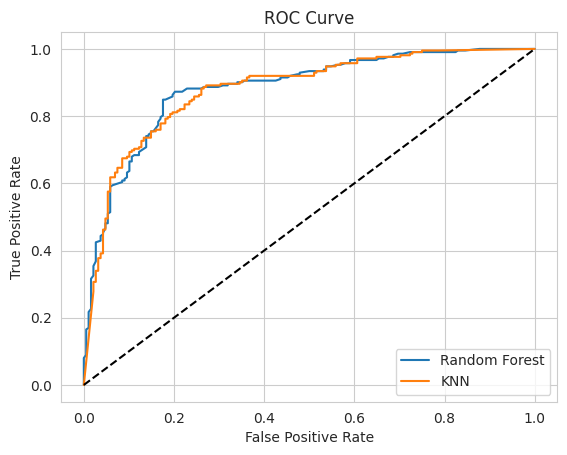

KNN  AUC: 0.8789140907266157
RF   AUC: 0.8819500200722601


In [27]:
# ROC Curve
y_prob_rf = rf_model.predict_proba(x_test)[:, 1]

fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_prob_rf)
plt.plot(fpr_rf, tpr_rf, label = "Random Forest")
plt.plot(fpr, tpr, label = "KNN")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print("KNN  AUC:", roc_auc_score(y_test, y_prob))
print("RF   AUC:", roc_auc_score(y_test, y_prob_rf))

### Q8 결과 해석

**선정 모델 : Random Forest** (KNN 제외 조건에 맞추어, 거리 기반이 아닌 앙상블 트리 모델을 선택했다. `n_estimators = 300`, 깊이 제한 없음의 임의 파라미터로 grid search 없이 학습했다.)

**(1) 성능 비교**

| | KNN (GridSearchCV 튜닝) | Random Forest (임의 파라미터) |
|---|---|---|
| Accuracy | 0.8025 | **0.8175** |
| f1-score (0: Low) | 0.79 | 0.81 |
| f1-score (1: High) | 0.81 | 0.82 |
| ROC-AUC | 0.8789 | **0.8820** |

- Random Forest가 **튜닝을 전혀 하지 않았음에도** 10-fold grid search로 최적화한 KNN보다 정확도가 약 1.5%p 높았다. AUC는 0.879 → 0.882로 거의 차이가 없어, ROC 곡선도 두 모델이 대부분 겹친다. 즉 **이 데이터에서 두 모델의 판별력 자체는 비슷하고, RF가 임계값 0.5 근처에서 조금 더 잘 나누고 있다.**
- 두 모델 모두 무작위 분류(대각선)보다 뚜렷하게 위에 위치하므로, 11개의 물리·화학적 측정값만으로 고/저품질을 구분하는 것은 충분히 유의미하다.

**(2) 클래스별 해석**
- 두 모델 공통적으로 **class 1(High quality)의 precision(0.84)이 recall(0.81)보다 높다.** 고품질이라고 예측한 와인은 대체로 실제 고품질이지만, 실제 고품질 와인 중 약 19%는 저품질로 잘못 분류해 놓치고 있다는 뜻이다. 반대로 class 0은 recall이 더 높아 저품질을 잡아내는 데 더 적극적이다.
- test set의 클래스 분포가 188(0) : 212(1)로 비교적 균형 잡혀 있어 accuracy가 왜곡되지 않으며, macro avg와 weighted avg가 동일하게 0.82로 나오는 것도 이를 뒷받침한다.

**(3) 모델 특성 관점에서의 해석**
- **Random Forest는 스케일링이 불필요하고 다중공선성에 강건하다.** Q4에서 확인한 `fixed acidity`–`pH`–`density`–`citric acid` 간의 강한 상관이 KNN에서는 '산도' 정보가 거리 계산에 중복 반영되는 문제를 일으키지만, 트리는 분기마다 하나의 변수만 사용하므로 이 영향이 작다. 또한 `alcohol`과 `volatile acidity`의 비선형적 효과나 변수 간 상호작용을 자동으로 잡아낼 수 있다는 점이 RF가 소폭 우위를 보인 이유로 해석된다.
- 반면 **KNN은 스케일링과 차원 수에 민감**하고, 예측 시점마다 전체 train 데이터와의 거리를 계산해야 해 데이터가 커질수록 비효율적이다. 다만 본 데이터는 1599개(train 1199개), 11차원으로 규모가 작아 KNN도 충분히 경쟁력 있는 성능을 냈다.

**(4) 한계 및 개선 방향**
- quality를 6 기준으로 이진화하면서 3~8의 순서 정보가 손실되었고, 원래 등급 3(10개)과 8(18개)처럼 극단 등급의 표본이 매우 적다.
- Random Forest에도 GridSearchCV(`max_depth`, `min_samples_leaf`, `max_features`)를 적용하거나 Gradient Boosting 계열을 사용하면 추가 성능 향상을 기대할 수 있다.
